
Processing CS2_35...
  -> Extracted 924 valid, filtered cycles.

Processing CS2_36...
  -> Extracted 909 valid, filtered cycles.

Processing CS2_37...
  -> Extracted 986 valid, filtered cycles.

Processing CS2_38...
  -> Extracted 1057 valid, filtered cycles.


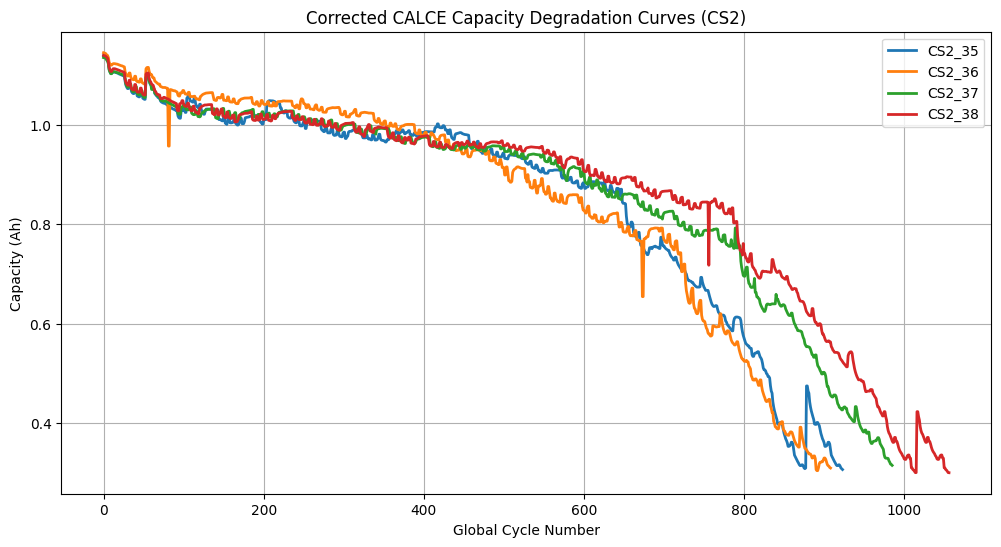


Total CALCE windows generated: (3680, 50, 1)
Saved: torch.Size([2944, 50, 1]) to calce_train_windows.pt
Saved: torch.Size([736, 50, 1]) to calce_test_windows.pt

Extraction Complete! Data is ready for the WGAN.


: 

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---
RAW_DATA_DIR = "../data/raw/calce/"
PROCESSED_DATA_DIR = "../data/processed/"
WINDOW_SIZE = 50
BATTERIES = ["CS2_35", "CS2_36", "CS2_37", "CS2_38"]

os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

def parse_date_from_filename(filepath):
    basename = os.path.basename(filepath)
    name_without_ext = os.path.splitext(basename)[0]
    parts = name_without_ext.split('_')
    try:
        year = int(parts[-1])
        day = int(parts[-2])
        month = int(parts[-3])
        if year < 50: year += 2000
        else: year += 1900
        return year, month, day
    except Exception as e:
        return 0, 0, 0

# --- 2. ROBUST CUMULATIVE EXTRACTION LOGIC ---
all_battery_capacities = {}

for battery in BATTERIES:
    print(f"\nProcessing {battery}...")
    battery_dir = os.path.join(RAW_DATA_DIR, battery)
    
    excel_files = glob.glob(os.path.join(battery_dir, "*.xlsx"))
    excel_files.sort(key=parse_date_from_filename)
    
    battery_capacity = []
    
    for file in excel_files:
        try:
            xls = pd.ExcelFile(file)
            df = None
            for sheet in xls.sheet_names:
                temp_df = pd.read_excel(xls, sheet_name=sheet)
                if 'Cycle_Index' in temp_df.columns and 'Discharge_Capacity(Ah)' in temp_df.columns:
                    df = temp_df
                    break
            
            if df is not None:
                # THE FIX: CALCE capacity is cumulative. 
                # Cycle Capacity = Max cumulative capacity - Min cumulative capacity within that cycle.
                cycle_caps = df.groupby('Cycle_Index')['Discharge_Capacity(Ah)'].agg(lambda x: x.max() - x.min())
                
                for cap in cycle_caps:
                    # CS2 rated capacity is 1.1 Ah. 
                    if 0.3 < cap < 1.3:
                        battery_capacity.append(cap)
            else:
                print(f"  -> Skipping {os.path.basename(file)}: Missing required columns.")
                
        except Exception as e:
            print(f"  -> Error reading {os.path.basename(file)}: {e}")
            
    # Apply a light rolling median to handle minor machine sensor jitters
    cap_array = np.array(battery_capacity)
    if len(cap_array) > 0:
        cap_series = pd.Series(cap_array)
        smoothed_caps = cap_series.rolling(window=3, min_periods=1, center=True).median().values
        all_battery_capacities[battery] = smoothed_caps
        print(f"  -> Extracted {len(smoothed_caps)} valid, filtered cycles.")

# --- 3. VISUAL VERIFICATION ---
plt.figure(figsize=(12, 6))
for battery, capacities in all_battery_capacities.items():
    plt.plot(capacities, label=battery, linewidth=2)
plt.title("Corrected CALCE Capacity Degradation Curves (CS2)")
plt.xlabel("Global Cycle Number")
plt.ylabel("Capacity (Ah)")
plt.legend()
plt.grid(True)
plt.show()

# --- 4. NORMALIZATION & WINDOWING ---
all_windows = []

for battery, capacities in all_battery_capacities.items():
    if len(capacities) < WINDOW_SIZE:
        print(f"Warning: {battery} has fewer than {WINDOW_SIZE} cycles. Skipping.")
        continue
        
    min_cap = np.min(capacities)
    max_cap = np.max(capacities)
    normalized_caps = 2 * ((capacities - min_cap) / (max_cap - min_cap)) - 1
    
    for i in range(len(normalized_caps) - WINDOW_SIZE + 1):
        window = normalized_caps[i : i + WINDOW_SIZE]
        all_windows.append(window)

# Safety check to prevent AxisError
if len(all_windows) == 0:
    print("\nCRITICAL ERROR: No valid windows were extracted. Check the extraction limits.")
else:
    all_windows = np.array(all_windows)
    all_windows = np.expand_dims(all_windows, axis=2)
    print(f"\nTotal CALCE windows generated: {all_windows.shape}")

    # --- 5. TRAIN/TEST SPLIT & SAVE ---
    np.random.seed(42)
    np.random.shuffle(all_windows)

    split_idx = int(len(all_windows) * 0.8)
    train_windows = all_windows[:split_idx]
    test_windows = all_windows[split_idx:]

    train_tensor = torch.tensor(train_windows, dtype=torch.float32)
    test_tensor = torch.tensor(test_windows, dtype=torch.float32)

    torch.save(train_tensor, os.path.join(PROCESSED_DATA_DIR, "calce_train_windows.pt"))
    torch.save(test_tensor, os.path.join(PROCESSED_DATA_DIR, "calce_test_windows.pt"))

    print(f"Saved: {train_tensor.shape} to calce_train_windows.pt")
    print(f"Saved: {test_tensor.shape} to calce_test_windows.pt")
    print("\nExtraction Complete! Data is ready for the WGAN.")

In [2]:
pip install openpyxl




   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openp